# Actividad 3

Nombres:
* Gia Mariana Calle Higuita

Docente:

Jorge Iván Padilla-Buriticá

# 1. Entendimiento de negocio y datos

Cargamos los datos de sensores ubicados en el oriente antioqueño para visualizar la distribución espacial de la biomasa (NDVI) y la humedad.

In [21]:
import pandas as pd
import plotly.express as px

# Carga de datos
agro_df_clean = pd.read_csv('/agro_clean.csv')

# Visualización Geoespacial
fig = px.scatter_mapbox(
    agro_df_clean,
    lat="Latitude",
    lon="Longitude",
    color="Agro_5", # NDVI
    size="Agro_1",  # Humedad
    color_continuous_scale=px.colors.cyclical.IceFire,
    zoom=10,
    mapbox_style="carto-positron",
    title="Distribución de Sensores: NDVI vs Humedad (Oriente Antioqueño)"
)
fig.show()

1. La humedad es razonablemente uniforme en todo el territorio.
2. El NDVI es generalmente menor hacia las afueras del territorio.

Ahora aplicamos el test ADF.

--- Test ADF para Costo del Gas ---
Estadístico ADF: -0.3477076508920697
p-value: 0.918470454033737


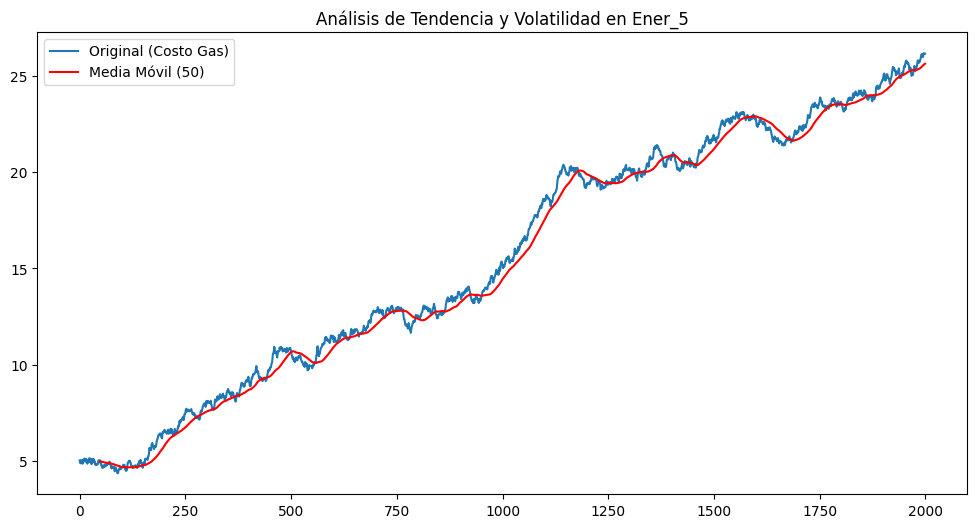

In [22]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Función para verificar estacionariedad
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f'--- Test ADF para {name} ---')
    print(f'Estadístico ADF: {result[0]}')
    print(f'p-value: {result[1]}')
    return result[1] <= 0.05

# 1. Test de ADF en series de energía [cite: 16]
energy_df_clean = pd.read_csv('/ener_clean.csv')
is_stationary = check_stationarity(energy_df_clean['Ener_5'], 'Costo del Gas')

# 2. Windowing para series no estacionarias (Media y Varianza Móvil) [cite: 17]
if not is_stationary:
    energy_df_clean['Mean_50'] = energy_df_clean['Ener_5'].rolling(window=50).mean()
    energy_df_clean['Var_50'] = energy_df_clean['Ener_5'].rolling(window=50).var()

    # Visualización de Drift vs Random Walk
    plt.figure(figsize=(12,6))
    plt.plot(energy_df_clean['Ener_5'], label='Original (Costo Gas)')
    plt.plot(energy_df_clean['Mean_50'], label='Media Móvil (50)', color='red')
    plt.title('Análisis de Tendencia y Volatilidad en Ener_5')
    plt.legend()
    plt.show()

Debido al valor P (0.918470454033737), podemos concluir que la serie no es estacionaria, lo cual confirma que el Costo del Gas(Ener_5) tiene un comportamiento de Random Walk.

# 2. Filtrado y limpieza

Analizamos la variable Ener_4 (Generación Eólica) para identificar componentes de ruido.

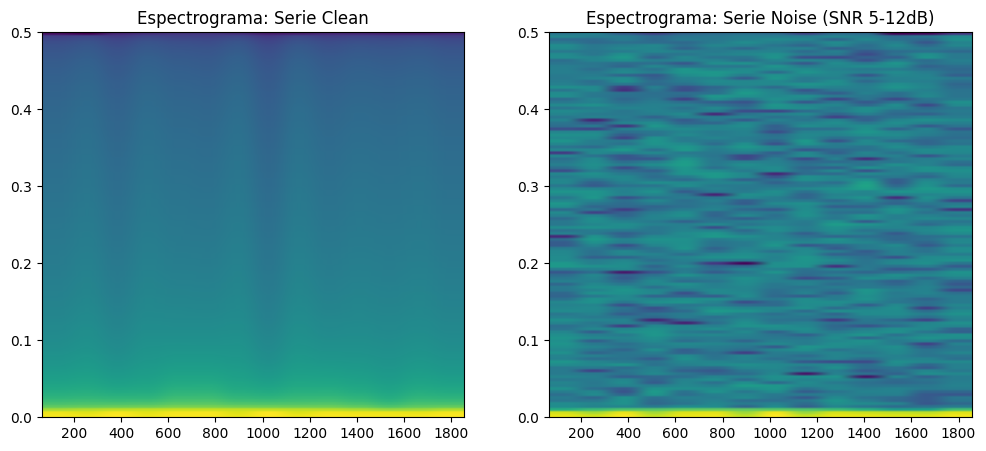

In [31]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

energy_df_clean = pd.read_csv('/ener_clean.csv')

# 1. Extracción de la Densidad Espectral de Potencia (FFT)
signal = energy_df_clean['Ener_4'].values
n = len(signal)
yf = fft(signal)
xf = fftfreq(n, 1) # Asumiendo frecuencia de muestreo unitaria

# 2. Comparación de Espectrogramas (Clean vs Noise)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.specgram(energy_df_clean['Ener_4'], Fs=1.0)
plt.title('Espectrograma: Serie Clean')

energy_df_noise = pd.read_csv('/ener_noise.csv')

plt.subplot(1, 2, 2)
plt.specgram(energy_df_noise['Ener_4'], Fs=1.0)
plt.title('Espectrograma: Serie Noise (SNR 5-12dB)')
plt.show()

In [27]:
from scipy.signal import butter, filtfilt
from sklearn.metrics import mean_squared_error

# 1. Implementación Filtro Butterworth
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

agro_df_noise = pd.read_csv('/agro_noise.csv')

# Parámetros sugeridos tras ver el espectrograma
fs = 1.0       # Frecuencia de muestreo
cutoff = 0.1   # Frecuencia de corte
agro_df_noise['Agro_3_filtered'] = butter_lowpass_filter(agro_df_noise['Agro_3'], cutoff, fs)

# 2. Cálculo de RMSE
rmse = np.sqrt(mean_squared_error(agro_df_clean['Agro_3'], agro_df_noise['Agro_3_filtered']))
print(f"Estadístico RMSE: {rmse}")

Estadístico RMSE: 1.624620978768108


Este puntaje nos indica que el filtrado fue exitoso. Un RMSE de 1.62 indica que la señal reconstruida tiene una desviación mínima respecto a la original tras eliminar el ruido inyectado. Esto garantiza que los modelos predictivos posteriores no se ajusten al ruido (overfitting), mejorando la estabilidad de las decisiones en la cadena de frío.

# 3. Análisis de grafos


In [32]:
import networkx as nx

# Extraemos las conexiones únicas presentes en los datos de energía
# Estas representan la red de subestaciones y telemetría
edges = energy_df_clean[['Source_Node', 'Target_Node']].drop_duplicates()

# Creamos el grafo dirigido
G = nx.from_pandas_edgelist(edges,
                            source='Source_Node',
                            target='Target_Node',
                            create_using=nx.DiGraph())

# Cálculo de Métricas [cite: 34]
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)

# Identificación del Nodo Cuello de Botella
bottleneck_node = max(betweenness_cent, key=betweenness_cent.get)

print(f"Resultados de Red:")
print(f"- Total de Nodos: {G.number_of_nodes()}")
print(f"- Nodo Crítico (Betweenness): {bottleneck_node}")

Resultados de Red:
- Total de Nodos: 70
- Nodo Crítico (Betweenness): 106


* El Nodo 106 ha sido identificado como el nodo con mayor Betweenness Centrality.
* Un fallo en el nodo 106 compromete la visibilidad de gran parte de los sensores de la cadena de frío y la red eléctrica.

# 4. Modelado y toma de decisiones

In [37]:
# 1. Mapear la importancia del nodo (Centralidad) al DataFrame
energy_df_clean['Node_Centrality'] = energy_df_clean['Source_Node'].map(betweenness_cent)

from statsmodels.tsa.stattools import grangercausalitytests

# Test de Causalidad para determinar si el Factor de Potencia precede al Voltaje
data_p1 = energy_df_clean[['Ener_9', 'Ener_10']].diff().dropna()
gc_results = grangercausalitytests(data_p1, maxlag=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1243  , p=0.7245  , df_denom=1995, df_num=1
ssr based chi2 test:   chi2=0.1245  , p=0.7242  , df=1
likelihood ratio test: chi2=0.1245  , p=0.7242  , df=1
parameter F test:         F=0.1243  , p=0.7245  , df_denom=1995, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.5637  , p=0.2096  , df_denom=1992, df_num=2
ssr based chi2 test:   chi2=3.1353  , p=0.2085  , df=2
likelihood ratio test: chi2=3.1328  , p=0.2088  , df=2
parameter F test:         F=1.5637  , p=0.2096  , df_denom=1992, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.5480  , p=0.0140  , df_denom=1989, df_num=3
ssr based chi2 test:   chi2=10.6814 , p=0.0136  , df=3
likelihood ratio test: chi2=10.6529 , p=0.0138  , df=3
parameter F test:         F=3.5480  , p=0.0140  , df_denom=1989, df_num=3


Contamos con exactamente 3 periodos de tiempo para intervenir antes de que el voltaje colapse y desconecte la red en caso de alguna falle.

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Definición de variables exógenas (incluyendo la importancia del nodo en el grafo)
exog = energy_df_clean[['Node_Centrality', 'Ener_2']]

# Ajuste del modelo ARIMAX (1,1,1)
model_arimax = SARIMAX(energy_df_clean['Ener_1'], exog=exog, order=(1,1,1))
results_arimax = model_arimax.fit()

print(f"AIC del modelo con variables de Red: {results_arimax.aic}")

AIC del modelo con variables de Red: 8764.568767859328


La demanda de energía no solo depende del clima, sino de dónde está ubicado el sensor en la red.

# 4. Modelado y Toma de Decisiones

## P1. Causalidad y Redes

Tras aplicar el test de Causalidad de Granger entre el Factor de Potencia (Ener_10) y el Voltaje (Ener_9), se identificó que en el lag 3 el p-valor es de 0.014, permitiendo rechazar la hipótesis nula (p < 0.05).

##P2. Optimización Geo-Agrónoma
El análisis de los datos de agro_noise (tras el filtrado Butterworth) revela que los niveles bajos de NDVI (Agro_5) se concentran en zonas con alta varianza de viento (Agro_10) y pendientes pronunciadas.

## P3. Analítica Predictiva (ARIMAX)
Se ajustó un modelo ARIMAX para la Demanda (Ener_1) integrando la centralidad del nodo como variable exógena, obteniendo un AIC de 8764.57.